In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import the smote algorithm from the imbalanced-learn library
from imblearn.over_sampling import SMOTE

pd.set_option('display.width', 120)

In [3]:
# load the pca files member 5 saved in the data folder
train_df = pd.read_csv('../data/train_pca.csv')
test_df = pd.read_csv('../data/test_pca.csv')

# separate features from the target
y_train = train_df['Bankrupt?']
X_train = train_df.drop(columns=['Bankrupt?'])

y_test = test_df['Bankrupt?']
X_test = test_df.drop(columns=['Bankrupt?'])

print("train set shape:", X_train.shape)
print("test set shape:", X_test.shape)

train set shape: (5455, 29)
test set shape: (1364, 29)


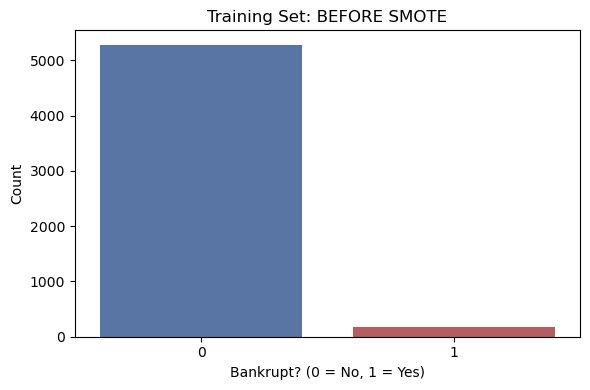

before smote counts:
 Bankrupt?
0    5279
1     176
Name: count, dtype: int64


In [4]:
# visual 1: target distribution before smote
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, hue=y_train, palette=['#4C72B0', '#C44E52'], legend=False)
plt.title('Training Set: BEFORE SMOTE')
plt.xlabel('Bankrupt? (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.tight_layout()

# save visual
plt.savefig('../results/eda_visualizations/member6_before_smote.png', dpi=110)
plt.show()

print("before smote counts:\n", y_train.value_counts())

In [5]:
# initialize SMOTE
smote = SMOTE(random_state=42)

# fit and resample ONLY the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("smote applied successfully to the training data.")

smote applied successfully to the training data.


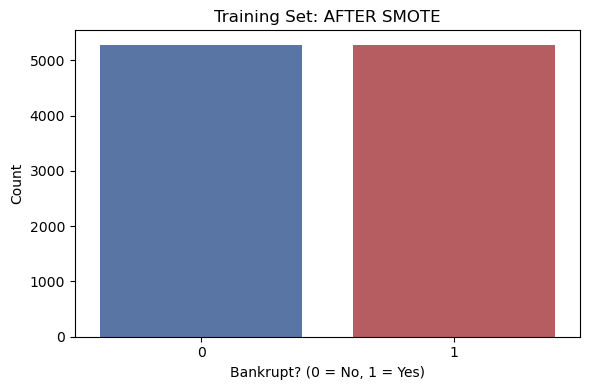

after smote counts:
 Bankrupt?
0    5279
1    5279
Name: count, dtype: int64


In [6]:
# visual 2: target distribution after smote
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_smote, hue=y_train_smote, palette=['#4C72B0', '#C44E52'], legend=False)
plt.title('Training Set: AFTER SMOTE')
plt.xlabel('Bankrupt? (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.tight_layout()

# save visual
plt.savefig('../results/eda_visualizations/member6_after_smote.png', dpi=110)
plt.show()

print("after smote counts:\n", y_train_smote.value_counts())

In [8]:
# build the final dataframes for modeling
train_final = X_train_smote.copy()
train_final['Bankrupt?'] = y_train_smote

# test set remains untouched by SMOTE
test_final = X_test.copy()
test_final['Bankrupt?'] = y_test

# 1. Save SMOTE files to data folder (to keep the group's pattern consistent)
train_final.to_csv('../data/train_smote.csv', index=False)
test_final.to_csv('../data/test_smote.csv', index=False)
print("saved train_smote.csv and test_smote.csv to data/")


saved train_smote.csv and test_smote.csv to data/
